# Using DBSCAN to Cluster Travel Review Data

In this notebook, we apply DBSCAN to explore if there are any hidden groups in the [Travel Reviews dataset](https://archive.ics.uci.edu/dataset/484/travel+reviews) from UC Irvine's Machine Learning Repository, and wheteher we can reduce this dataset to lower dimensions. This dataset contains data about 980 TripAdvisor.com user reviews on different destinations in East Asia. and it contains 10 features (with nondescript names):

| **Feature**       | **Type**   | **Decsription**                                 |
| ----------------- | ---------- | -----------------                               |
| **Category 1**    | Continuous | Average user feedback on art galleries          |
| **Category 2**    | Continuous | Average user feedback on dance clubs            |
| **Category 3**    | Continuous | Average user feedback on juice bars             |
| **Category 4**    | Continuous | Average user feedback on restaurants            |
| **Category 5**    | Continuous | Average user feedback on museums                |
| **Category 6**    | Continuous | Average user feedback on resorts                | 
| **Category 7**    | Continuous | Average user feedback on parks/picnic spots     |
| **Category 8**    | Continuous | Average user feedback on beaches                |
| **Category 9**    | Continuous | Average user feedback on theaters               |
| **Category 10**   | Continuous | Average user feedback on religious institutions |

The dataset information summary explains that "each traveler rating is mapped as Excellent (4), Very Good (3), Average (2), Poor (1), and Terrible (0) and average rating is used against each category per user." The goal of using DBSCAN here is to discover natural groupings of travelers based on their preference profiles, such as if some users prefer cultural venues (museums, galleries, theaters) while others prefer outdoor/leisure (parks, beaches, resorts).

---

## Load and Explore Data

In [55]:
# Import relevant pacakges
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

from ml_package import DBSCAN, PCA, StandardScaler


In [5]:
df = pd.read_csv('tripadvisor_review.csv')

# Rename categories to descriptive labels
category_names = {
    'Category 1':  'Art Galleries',
    'Category 2':  'Dance Clubs',
    'Category 3':  'Juice Bars',
    'Category 4':  'Restaurants',
    'Category 5':  'Museums',
    'Category 6':  'Resorts',
    'Category 7':  'Parks/Outdoor',
    'Category 8':  'Beaches',
    'Category 9':  'Theaters',
    'Category 10': 'Religious Sites',
}
df = df.rename(columns=category_names)
feature_cols = list(category_names.values())
df.head()

,User ID,Art Galleries,Dance Clubs,Juice Bars,Restaurants,Museums,Resorts,Parks/Outdoor,Beaches,Theaters,Religious Sites
0,User 1,0.93,1.8,2.29,0.62,0.80,2.42,3.19,2.79,1.82,2.42
1,User 2,1.02,2.2,2.66,0.64,1.42,3.18,3.21,2.63,1.86,2.32
2,User 3,1.22,0.8,0.54,0.53,0.24,1.54,3.18,2.80,1.31,2.50
3,User 4,0.45,1.8,0.29,0.57,0.46,1.52,3.18,2.96,1.57,2.86
4,User 5,0.51,1.2,1.18,0.57,1.54,2.02,3.18,2.78,1.18,2.54


In [56]:
# Descriptive statistics
df[feature_cols].describe().round(3)

,Art Galleries,Dance Clubs,Juice Bars,Restaurants,Museums,Resorts,Parks/Outdoor,Beaches,Theaters,Religious Sites
count,980.000,980.000,980.000,980.000,980.000,980.000,980.000,980.000,980.000,980.000
mean,0.893,1.353,1.013,0.532,0.940,1.843,3.181,2.835,1.569,2.799
std,0.327,0.478,0.789,0.280,0.437,0.540,0.008,0.138,0.365,0.321
min,0.340,0.000,0.130,0.150,0.060,0.140,3.160,2.420,0.740,2.140
25%,0.670,1.080,0.270,0.410,0.640,1.460,3.180,2.740,1.310,2.540
50%,0.830,1.280,0.820,0.500,0.900,1.800,3.180,2.820,1.540,2.780
75%,1.020,1.560,1.572,0.580,1.200,2.200,3.180,2.910,1.760,3.040
max,3.220,3.640,3.620,3.440,3.300,3.760,3.210,3.390,3.170,3.660


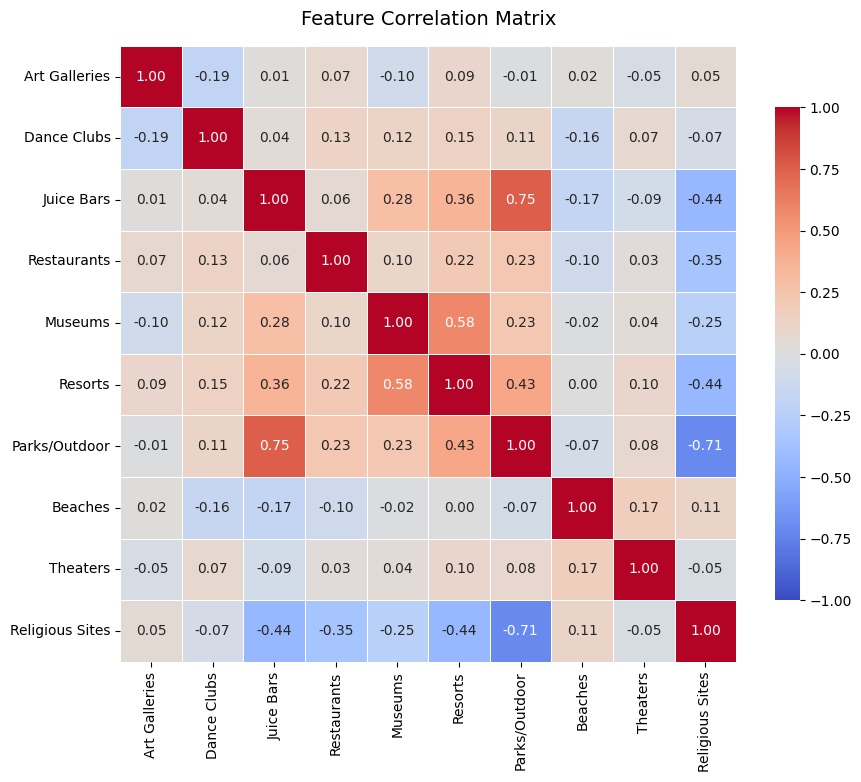

In [13]:
# Create a correlation heatmap of the features 
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[feature_cols].corr()
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.show()

---

The correlation heatmap of the features shows that across most feature pairs, there is little or moderate correlation. The strongest positive pairs are between Parks/Outdoors and Juice Bars, which may suggest a traveler who likes to be out and about, and between Resorts and Museums, which may suggest a traveler who prefers a more structured vaction. The strongest negative pairs are between Parks/Outdoors and Religious Sites, and between Resorts and Religious Sites, which may suggest that travelers to religious sites have uniquely different interests compared to other travelers. Of course, these pairwise interpretations are subjective, so we will proceed with our DBSCAN algorithm to see if any hidden groups and patterns can be found. 

---

## Scale Data and Select Hyperparameters

---

DBSCAN uses distance metrics (Euclidean by default), so features must be on the same scale. We apply StandardScaler to normalize each feature to zero mean and unit variance.

---

In [17]:
X = df[feature_cols].values

# Fit and transform using the custom StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


---

DBSCAN has two key parameters:
* eps: The neighborhood radius. Points within eps distance of a core point are considered neighbors.
* min_samples: Minimum number of points required in an neighborhood radius to qualify as a core point.

A standard heuristic is to plot the k-th nearest neighbor distances (sorted in ascending order) for k = min_samples. The "elbow" point (where the curve bends sharply) is a good candidate for the neighborhood radius.

---

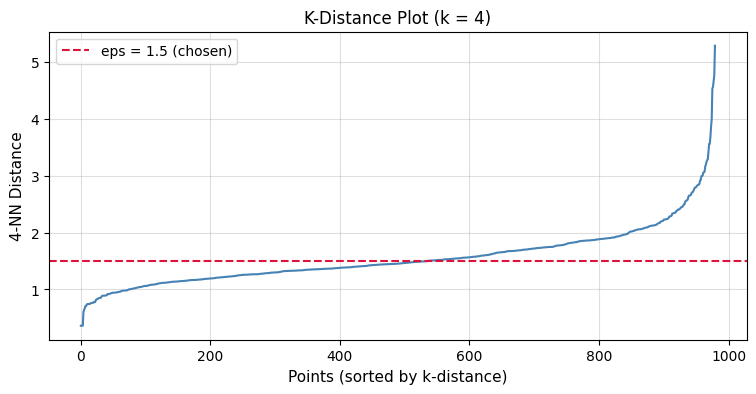

Chosen hyperparameters: eps = 1.5, min_samples = 4


In [50]:
# Use SK-Learn's unsupervised nearest neighbors
# Start with min_samples at 4 
min_samples = 4

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1]) 

# Plot elbow guides eps selection'
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color='steelblue', linewidth=1.5)
ax.axhline(y=1.5, color='crimson', linestyle='--', linewidth=1.5, label='eps = 1.5 (chosen)')
ax.set_xlabel('Points (sorted by k-distance)', fontsize=11)
ax.set_ylabel(f'{min_samples}-NN Distance', fontsize=11)
ax.set_title(f'K-Distance Plot (k = {min_samples})', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.show()

print(f'Chosen hyperparameters: eps = 1.5, min_samples = {min_samples}')

## Fit DBSCAN

---

Now that we found our hyperparameter values, we can fit the DBSCAN algorithm.

---

In [51]:
eps         = 1.5
min_samples = 4

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = np.sum(labels == -1)
noise_pct  = 100 * n_noise / len(labels)

print(f'Number of clusters found : {n_clusters}')
print(f'Noise points (label = -1): {n_noise}  ({noise_pct:.1f}% of dataset)')
print(f'\nCluster label counts:')
unique, counts = np.unique(labels, return_counts=True)
for lbl, cnt in zip(unique, counts):
    name = f'Cluster {lbl}' if lbl != -1 else 'Noise'
    print(f'  {name:>12}: {cnt:>4} points ({100*cnt/len(labels):.1f}%)')

Number of clusters found : 9
Noise points (label = -1): 304  (31.0% of dataset)

Cluster label counts:
         Noise:  304 points (31.0%)
   Cluster 0.0:  644 points (65.7%)
   Cluster 1.0:    4 points (0.4%)
   Cluster 2.0:    2 points (0.2%)
   Cluster 3.0:    4 points (0.4%)
   Cluster 4.0:    4 points (0.4%)
   Cluster 5.0:    5 points (0.5%)
   Cluster 6.0:    5 points (0.5%)
   Cluster 7.0:    4 points (0.4%)
   Cluster 8.0:    4 points (0.4%)


---

For this dataset, DBSCAN found eight unique clusters (plus one noise "cluster"). However, the data was overwhelmingly grouped into the first cluster, which contains about 65.7% of the observations. The other seven clusters the algorithm found were much smaller, each representing only about combined 0.4% to 0.5% of the observations. Outside the clusters, DBSCAN labeled about 31.0% of the dataset as noise. Thus, while the algorithm wasn't too helpful in finding more balanced clusters that would represent unique traveler archetypes, it did help us potentially find one dominate traveler archetype.


The results DBSCAN provides are heavily dependent on the neighborhood radius. While we used unsupervised nearest neighbors to help us choose the radius earlier, it may still be useful to sweep a range of radius values and track how the number of clusters and noise rate change. 

---

  eps=0.3  n_clusters=0  noise=980
  eps=0.5  n_clusters=1  noise=976
  eps=0.7  n_clusters=3  noise=967
  eps=0.9  n_clusters=13  noise=907
  eps=1.1  n_clusters=23  noise=759
  eps=1.3  n_clusters=16  noise=530
  eps=1.5  n_clusters=9  noise=304
  eps=2.0  n_clusters=5  noise=74


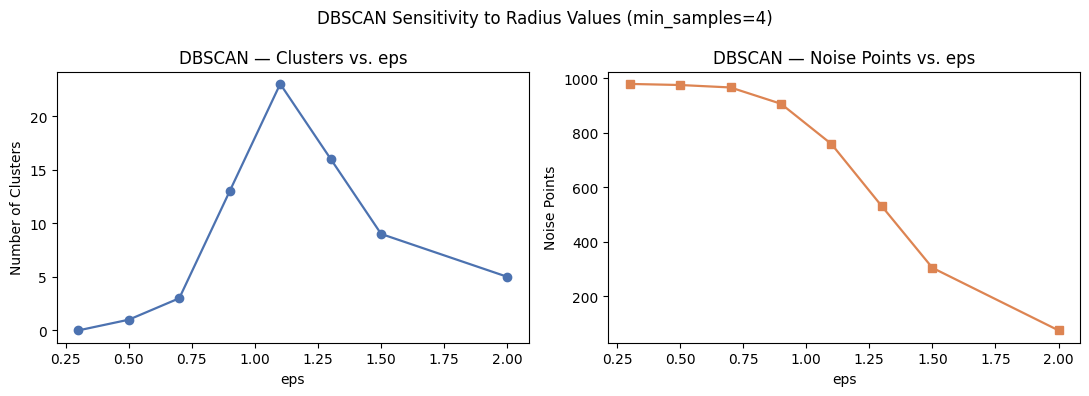

In [53]:
# List of radius values to sweep over
eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 2.0]
n_clusters_list = []
n_noise_list = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=4)
    db.fit(X_scaled)
    lbl = db.labels_
    n_clust = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise = (lbl == -1).sum()
    n_clusters_list.append(n_clust)
    n_noise_list.append(n_noise)
    print(f"  eps={eps:.1f}  n_clusters={n_clust}  noise={n_noise}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(eps_values, n_clusters_list, "o-", color="#4C72B0", linewidth=1.6)
ax1.set_xlabel("eps"); ax1.set_ylabel("Number of Clusters")
ax1.set_title("DBSCAN — Clusters vs. eps")
ax2.plot(eps_values, n_noise_list, "s-", color="#DD8452", linewidth=1.6)
ax2.set_xlabel("eps"); ax2.set_ylabel("Noise Points")
ax2.set_title("DBSCAN — Noise Points vs. eps")
plt.suptitle("DBSCAN Sensitivity to Radius Values (min_samples=4)", fontsize=12)
plt.tight_layout()
plt.show()

---

From these graphs, we see that the number of clusters peaks when the radius is around 1.10. We also see that increasing the radius beyond this point yields similar numbers of clusters to smaller radius values, but that there are fewer noise points with the larger radii, which is helpful for determining clusters.

Now, we can plot the clusters. Since the data lives in ten dimensions, we use PCA to reduce to two dimensions for visualization. The first two principal components capture the dominant directions of variance.

---

PCA explained variance: PC1=29.8%, PC2=12.6%, Total=42.4%


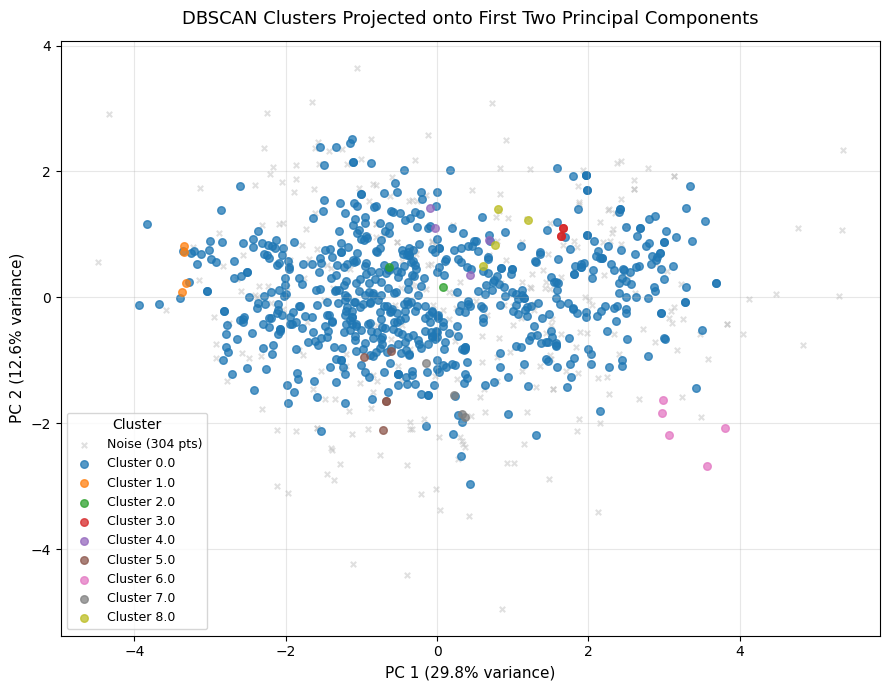

In [54]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PCA explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, '
      f'Total={sum(explained):.1%}')

# Build color map: noise = gray, clusters = distinct colors
unique_labels = sorted(set(labels))
cluster_ids   = [l for l in unique_labels if l != -1]
palette       = sns.color_palette('tab10', len(cluster_ids))
color_map     = {lbl: palette[i] for i, lbl in enumerate(cluster_ids)}
color_map[-1] = (0.7, 0.7, 0.7)  # gray for noise

fig, ax = plt.subplots(figsize=(9, 7))

for lbl in unique_labels:
    mask  = labels == lbl
    color = color_map[lbl]
    name  = f'Cluster {lbl}' if lbl != -1 else f'Noise ({np.sum(mask)} pts)'
    marker = 'x' if lbl == -1 else 'o'
    size   = 15 if lbl == -1 else 30
    alpha  = 0.4 if lbl == -1 else 0.75
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[color], marker=marker, s=size, alpha=alpha, label=name)

ax.set_xlabel(f'PC 1 ({explained[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC 2 ({explained[1]:.1%} variance)', fontsize=11)
ax.set_title('DBSCAN Clusters Projected onto First Two Principal Components',
             fontsize=13, pad=12)
ax.legend(title='Cluster', fontsize=9, title_fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

The plot of the clusters is helpful in seeing where the clusters are located. While cluster 0.0 is overwhelmingly some of the other clusters (such as clusters 1.0, 6.0, 8.0) may represent other meaningful traveler archetypes. With additional data, we may be able to determine if these would be sizable groups or not. 

Overall, DBSCAN was able to identify eight different potential traveler archetypes, with most observations fitting into one group. DBSCAN was not able to partition the data into more unique clusters, implying that it may be more useful on data that is already more separated.

---